# VAE latent interpolation: crossfade or motion?

`docs/IMPLEMENTATION_TRICKS.md` claims that "VAE latent spaces possess strong geometric continuity". This notebook
tests that claim directly on the frozen `kl-f8` VAE that SDSeg uses as its first-stage autoencoder (the codec that
turns segmentation masks into the latents the UNet diffuses).

**Competing hypotheses for `z = 0.5 * z_A + 0.5 * z_B`, where `z_A` and `z_B` are the latents of two vertebra masks
at different positions:**

- **Geometric continuity**: the VAE latent space is locally linear with respect to spatial layout, so `z` decodes to
  a single vertebra roughly halfway between the two positions.
- **Crossfade**: the VAE only interpolates pixel intensity, not position, so `z` decodes to two faint "ghost"
  vertebrae, each at ~50% intensity, sitting at the original positions of A and B.

**Method**: pick two labeled frames from the same VFSS video with no other labeled frame between them, encode both
the image and the mask with the SDSeg VAE, linearly interpolate the latents, decode the sweep, and inspect the
result both visually and with a simple connected-component / centroid analysis.

## Reasoning map

1. SDSeg's segmentation target (`first_stage_key: "segmentation"`) is encoded/decoded by a frozen `AutoencoderKL`
   (the `kl-f8` checkpoint downloaded by `scripts/download_first_stages_f8.sh`). This is the exact VAE referenced by
   the claim under test, and it never gets fine-tuned as part of SDSeg training (see
   `docs/IMPLEMENTATION_TRICKS.md`, "frozen first-stage vs. trainable conditioner").
2. `ldm.data.vfss_new.VFSSWindowImageDataset` exposes the parsed frame table as `dataset.video_frame_df` — one row
   per *labeled* frame. Sorting by `(video_id, frame_id)` and taking consecutive rows within the same video directly
   gives a pair of labeled frames with no other labeled frame in between.
3. We use `posterior.mode()` (the Gaussian mean) rather than `.sample()` when encoding, so the experiment is
   deterministic and isn't confounded by sampling noise.
4. Because `scale_factor` in `LatentDiffusion`/`SDSeg` is just a single global scalar, it does not affect whether
   interpolation looks linear or not — `interp(s*z_A, s*z_B) = s*interp(z_A, z_B)` — so we work with raw
   `AutoencoderKL` latents directly and never need to build a full `SDSeg`/UNet model for this test.

In [1]:
# Edit these before running the notebook.
notebook_config = {
    "dataset_path": "/data_ssd/caioseda/data/dataset_inca_all_frames/",
    "size": 256,
    # Config to source the frozen first-stage VAE from (any VFSS config works, they share the same kl-f8 checkpoint).
    "vae_config_path": "configs/SDSeg/vfss-new-inca-window-3.yaml",
    "split": "train",
    # Prefer this video_id if it has an eligible frame pair; otherwise fall back to the pair with the largest
    # frame gap across the whole split (more frame gap -> more likely to show visible motion).
    "preferred_video_id": 21,
    # Index into the (optionally video-filtered) pairs table, sorted by descending frame_gap. Bump this to explore
    # a different pair without re-running the cells above it.
    "pair_index": 0,
    "num_interp_steps": 9,  # alpha = linspace(0, 1, num_interp_steps)
    "binarize_threshold": 0.0,  # decoded masks live in ~[-1, 1]; 0 is the natural background/foreground split
    "min_component_area": 8,  # drop connected components smaller than this many pixels (VAE reconstruction speckle)
    "device": "cuda",  # falls back to "cpu" automatically if CUDA isn't available
    "video_num_frames": 30,  # frames for one forward A->B sweep
    "video_fps": 12,
    "video_ping_pong": True,  # append the reversed sweep so the clip loops seamlessly (A->B->A)
    "video_output_dir": "outputs/vae_latent_interpolation",  # gitignored scratch dir, same convention as scripts/slice2seg.py
}

In [2]:
import os
import sys
from pathlib import Path

# Make this notebook work when launched either from the repo root or from notebooks/.
repo = Path.cwd()
if repo.name == "notebooks":
    repo = repo.parent
os.chdir(repo)
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import imageio
from omegaconf import OmegaConf
from scipy import ndimage as ndi
from IPython.display import Video

from ldm.data.vfss_new import VFSSWindowImageDataset
from ldm.util import instantiate_from_config

device = torch.device(notebook_config["device"] if torch.cuda.is_available() else "cpu")
print("repo root:", repo)
print("device:", device)

repo root: /data_ssd/caioseda/projetos/Stable-Diffusion-Seg
device: cuda


## Load the VFSS dataset and find a labeled frame pair

`window_size=1` is enough here — the temporal window used for TCM conditioning is irrelevant to this test, we just
need single image/mask pairs.

In [3]:
dataset = VFSSWindowImageDataset(
    dataset_path=notebook_config["dataset_path"],
    size=notebook_config["size"],
    window_size=1,
    stride=1,
    repeat_channels=True,
    split=notebook_config["split"],
)
print(f"{notebook_config['split']} split: {len(dataset)} labeled frames")
dataset.video_frame_df.head()

train split: 568 labeled frames


,video_frame,video_id,frame_id,batch,selected_labeler,video_path,target_dir,split,image_path,target_path
0,v100_f10,100,10,5,VC,videos/100.avi,rotulos/anotacoes-tecgraf/all/batch-5/VC/v100_f10,train,train/data/100/10.png,train/target/v100_f10.tif
1,v100_f12,100,12,2,AM,videos/100.avi,rotulos/anotacoes-tecgraf/all/batch-2/AM/v100_f12,train,train/data/100/12.png,train/target/v100_f12.tif
2,v100_f13,100,13,3,BB,videos/100.avi,rotulos/anotacoes-tecgraf/all/batch-3/BB/v100_f13,train,train/data/100/13.png,train/target/v100_f13.tif
3,v100_f14,100,14,4,BB,videos/100.avi,rotulos/anotacoes-tecgraf/all/batch-4/BB/v100_f14,train,train/data/100/14.png,train/target/v100_f14.tif
4,v100_f15,100,15,5,VC,videos/100.avi,rotulos/anotacoes-tecgraf/all/batch-5/VC/v100_f15,train,train/data/100/15.png,train/target/v100_f15.tif


In [4]:
# Build every (frame_id -> next labeled frame_id) pair within each video, sorted by descending frame gap.
frame_table = dataset.video_frame_df.sort_values(["video_id", "frame_id"]).reset_index(drop=True)
frame_table["next_frame_id"] = frame_table.groupby("video_id")["frame_id"].shift(-1)
frame_table["frame_gap"] = frame_table["next_frame_id"] - frame_table["frame_id"]

pairs = frame_table.dropna(subset=["frame_gap"]).copy()
pairs["next_frame_id"] = pairs["next_frame_id"].astype(int)
pairs["frame_gap"] = pairs["frame_gap"].astype(int)
pairs = pairs.sort_values("frame_gap", ascending=False).reset_index(drop=True)

preferred_video_id = notebook_config["preferred_video_id"]
candidates = pairs[pairs.video_id == preferred_video_id] if preferred_video_id is not None else pairs
if len(candidates) == 0:
    print(f"No eligible pair for video_id={preferred_video_id}, falling back to the whole {notebook_config['split']} split.")
    candidates = pairs

selected = candidates.iloc[notebook_config["pair_index"]]
video_id = int(selected.video_id)
frame_a_id = int(selected.frame_id)
frame_b_id = int(selected.next_frame_id)

print(f"Selected video_id={video_id}, frame_a={frame_a_id}, frame_b={frame_b_id}, frame_gap={selected.frame_gap}")
candidates.head()

Selected video_id=21, frame_a=26, frame_b=86, frame_gap=60


,video_frame,video_id,frame_id,batch,selected_labeler,video_path,target_dir,split,image_path,target_path,next_frame_id,frame_gap
91,v21_f26,21,26,4,BB,videos/21.avi,rotulos/anotacoes-tecgraf/all/batch-4/BB/v21_f26,train,train/data/21/26.png,train/target/v21_f26.tif,86,60
274,v21_f12,21,12,2,BB,videos/21.avi,rotulos/anotacoes-tecgraf/all/batch-2/BB/v21_f12,train,train/data/21/12.png,train/target/v21_f12.tif,26,14


In [5]:
sample_a = dataset.__getitem__(video_id=video_id, frame_id=frame_a_id)
sample_b = dataset.__getitem__(video_id=video_id, frame_id=frame_b_id)

for name, sample in [("A", sample_a), ("B", sample_b)]:
    img, seg = sample["image"], sample["segmentation"]
    print(f"frame {name}: image {tuple(img.shape)} range [{img.min():.2f}, {img.max():.2f}], "
          f"mask {tuple(seg.shape)} range [{seg.min():.2f}, {seg.max():.2f}]")

frame A: image (256, 256, 3) range [-1.00, 0.99], mask (256, 256, 3) range [-1.00, 1.00]
frame B: image (256, 256, 3) range [-1.00, 1.00], mask (256, 256, 3) range [-1.00, 1.00]


## Look at the raw frame pair

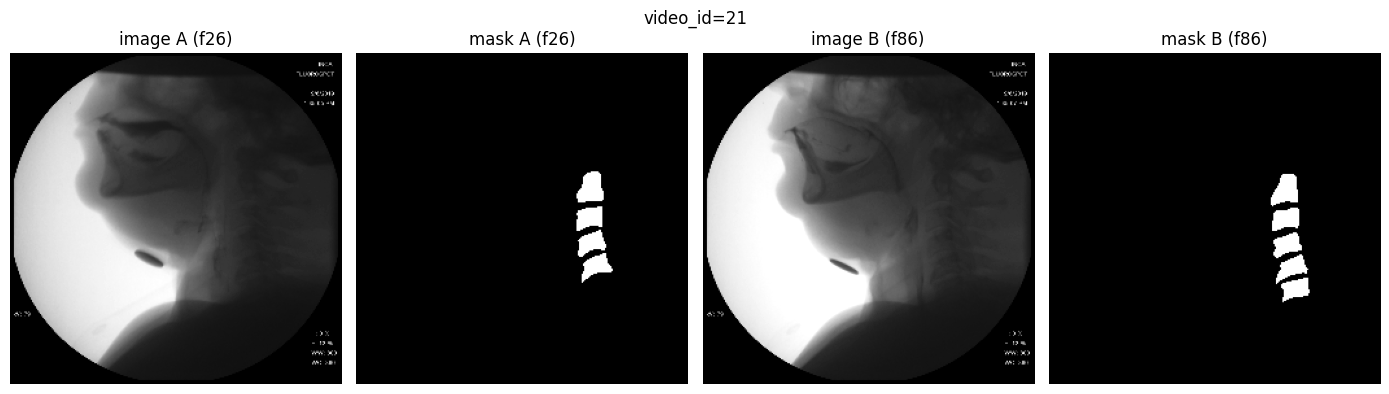

In [6]:
def hwc_to_display(x_hwc):
    x = x_hwc.float()[..., 0].numpy()
    return np.clip((x + 1.0) / 2.0, 0.0, 1.0)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, title, tensor in zip(
    axes,
    [f"image A (f{frame_a_id})", f"mask A (f{frame_a_id})", f"image B (f{frame_b_id})", f"mask B (f{frame_b_id})"],
    [sample_a["image"], sample_a["segmentation"], sample_b["image"], sample_b["segmentation"]],
):
    ax.imshow(hwc_to_display(tensor), cmap="gray")
    ax.set_title(title)
    ax.axis("off")
fig.suptitle(f"video_id={video_id}")
fig.tight_layout()

## Load the frozen SDSeg VAE (first-stage `AutoencoderKL`)

Same `kl-f8` checkpoint SDSeg uses to encode/decode the segmentation target during training, loaded standalone so
we don't need a trained SDSeg/UNet checkpoint for this experiment.

In [7]:
vae_config = OmegaConf.load(repo / notebook_config["vae_config_path"])
vae = instantiate_from_config(vae_config.model.params.first_stage_config)
vae.eval()
for p in vae.parameters():
    p.requires_grad_(False)
vae = vae.to(device)
print("VAE ready on", device)

/home/caioseda/miniconda3/envs/sdseg-cpython/lib/python3.9/site-packages/torchmetrics/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Restored KL-first-stage-model from models/first_stage_models/kl-f8/model.ckpt with 0 missing and 56 unexpected keys
VAE ready on cuda


## Encode / decode / interpolate helpers

In [8]:
def to_batch(x_hwc):
    """(H, W, C) in [-1, 1] -> (1, C, H, W) on `device`, matching DDPM.get_input's layout."""
    x = x_hwc.float()
    if x.ndim == 3:
        x = x.unsqueeze(0)
    x = x.permute(0, 3, 1, 2).contiguous()
    return x.to(device)


@torch.no_grad()
def encode_mode(x_bchw):
    """Deterministic latent: the mean of the encoder's Gaussian posterior, not a stochastic sample."""
    return vae.encode(x_bchw).mode()


@torch.no_grad()
def decode(z):
    return vae.decode(z)


def lerp(z_a, z_b, alpha):
    return (1 - alpha) * z_a + alpha * z_b


def to_display(x_bchw):
    """(1, C, H, W) decoded tensor -> displayable (H, W) grayscale in [0, 1]."""
    x = x_bchw[0].mean(dim=0).detach().cpu().numpy()
    return np.clip((x + 1.0) / 2.0, 0.0, 1.0)

## Encode both frames into VAE latents

In [9]:
mask_a, mask_b = to_batch(sample_a["segmentation"]), to_batch(sample_b["segmentation"])
image_a, image_b = to_batch(sample_a["image"]), to_batch(sample_b["image"])

z_mask_a, z_mask_b = encode_mode(mask_a), encode_mode(mask_b)
z_image_a, z_image_b = encode_mode(image_a), encode_mode(image_b)

print("mask latent:", tuple(z_mask_a.shape), "mean/std A:", z_mask_a.mean().item(), z_mask_a.std().item())
print("mask latent:", tuple(z_mask_b.shape), "mean/std B:", z_mask_b.mean().item(), z_mask_b.std().item())

mask latent: (1, 4, 32, 32) mean/std A: -1.2683037519454956 8.291348457336426
mask latent: (1, 4, 32, 32) mean/std B: -1.250882625579834 8.18441390991211


## Linear interpolation sweep — masks (the actual hypothesis test)

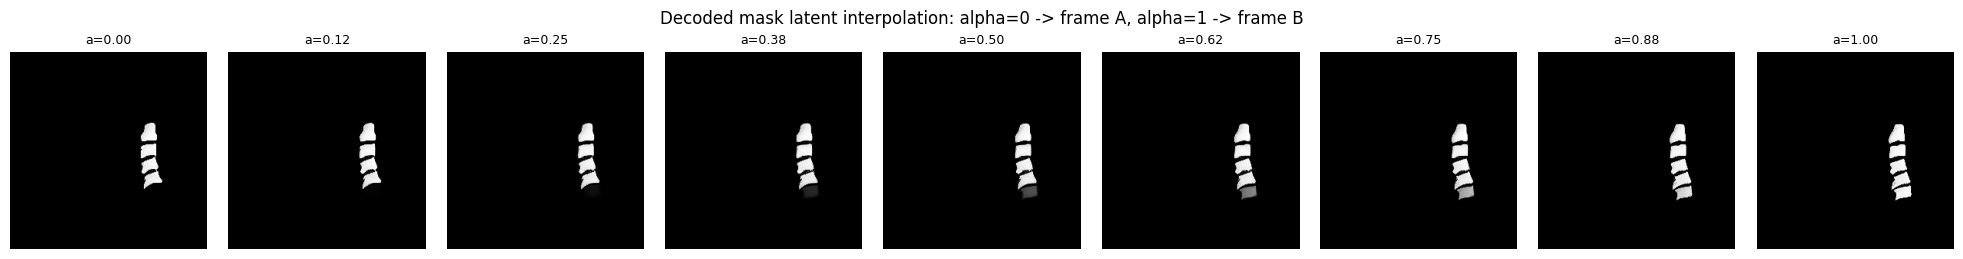

In [10]:
alphas = np.linspace(0.0, 1.0, notebook_config["num_interp_steps"])
decoded_masks = [decode(lerp(z_mask_a, z_mask_b, a)) for a in alphas]

fig, axes = plt.subplots(1, len(alphas), figsize=(2.2 * len(alphas), 2.6))
for ax, a, dec in zip(axes, alphas, decoded_masks):
    ax.imshow(to_display(dec), cmap="gray")
    ax.set_title(f"a={a:.2f}", fontsize=9)
    ax.axis("off")
fig.suptitle("Decoded mask latent interpolation: alpha=0 -> frame A, alpha=1 -> frame B")
fig.tight_layout()

## Linear interpolation sweep — images (context, not the hypothesis under test)

The same VAE also underlies SDSeg's image conditioning path. Interpolating photographic frames is a weaker test
(smooth intensity blending is a plausible outcome for overlapping anatomy even without geometric continuity), but
it's a useful visual reference alongside the mask sweep above.

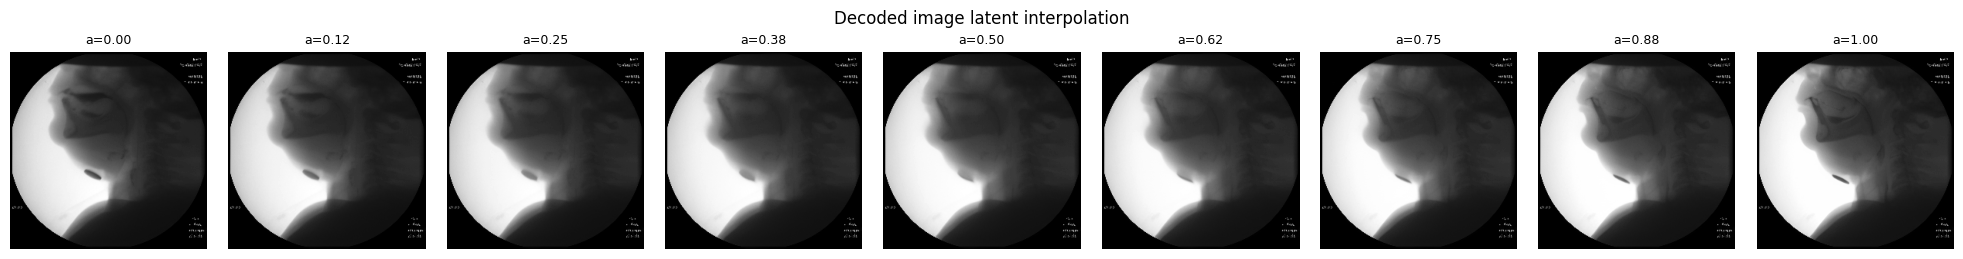

In [11]:
decoded_images = [decode(lerp(z_image_a, z_image_b, a)) for a in alphas]

fig, axes = plt.subplots(1, len(alphas), figsize=(2.2 * len(alphas), 2.6))
for ax, a, dec in zip(axes, alphas, decoded_images):
    ax.imshow(to_display(dec), cmap="gray")
    ax.set_title(f"a={a:.2f}", fontsize=9)
    ax.axis("off")
fig.suptitle("Decoded image latent interpolation")
fig.tight_layout()

## Render an alpha-sweep video

Static strips only show a handful of fixed points. A smooth animated sweep over many more `alpha` values is often a
more convincing way to judge whether the shape *moves* continuously or whether it just *fades* between two fixed
locations — motion reads as motion when it's playing, in a way that's harder to see in a strip of thumbnails. The
clip renders mask and image side by side and loops forward-then-backward (`video_ping_pong`) so it plays seamlessly.

In [12]:
def render_frame(alpha, figsize=(6, 3), dpi=100):
    dec_mask = decode(lerp(z_mask_a, z_mask_b, alpha))
    dec_image = decode(lerp(z_image_a, z_image_b, alpha))
    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi)
    axes[0].imshow(to_display(dec_mask), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("mask")
    axes[1].imshow(to_display(dec_image), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("image")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"alpha = {alpha:.3f}")
    fig.tight_layout()
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()  # fixed figsize/dpi -> constant frame shape
    plt.close(fig)
    return frame


forward_alphas = np.linspace(0.0, 1.0, notebook_config["video_num_frames"])
if notebook_config["video_ping_pong"]:
    video_alphas = np.concatenate([forward_alphas, forward_alphas[::-1][1:-1]])
else:
    video_alphas = forward_alphas

video_frames = [render_frame(a) for a in video_alphas]

video_dir = repo / notebook_config["video_output_dir"]
video_dir.mkdir(parents=True, exist_ok=True)
video_path = video_dir / f"alpha_sweep_v{video_id}_f{frame_a_id}_f{frame_b_id}.mp4"
imageio.mimwrite(video_path, video_frames, fps=notebook_config["video_fps"], quality=8, macro_block_size=1)
print(f"wrote {len(video_frames)} frames to {video_path} ({video_path.stat().st_size / 1024:.1f} KB)")

Video(str(video_path), embed=True, html_attributes="loop autoplay controls")

[swscaler @ 0xe848540] Warning: data is not aligned! This can lead to a speed loss


wrote 58 frames to /data_ssd/caioseda/projetos/Stable-Diffusion-Seg/outputs/vae_latent_interpolation/alpha_sweep_v21_f26_f86.mp4 (157.5 KB)


## Quantitative check: does the blob move, or do two ghosts blend?

For each decoded mask in the sweep: binarize at `binarize_threshold`, drop connected components smaller than
`min_component_area` (VAE reconstruction speckle, not anatomy), then measure total foreground area and the
foreground centroid.

- **Crossfade** predicts a centroid that jumps or stays split between two components pinned near A's and B's
  locations, rather than sliding continuously.
- **Geometric continuity** predicts a centroid that moves roughly monotonically from A's centroid to B's as `alpha`
  goes from 0 to 1, with area changing smoothly rather than doubling up.

This is a coarse signal, not a proof — always cross-check against the visual strip above.

In [13]:
def mask_stats(dec_bchw, threshold, min_component_area):
    arr = dec_bchw.mean(dim=1)[0].detach().cpu().numpy()
    binary = arr > threshold
    labeled, n_raw = ndi.label(binary)
    sizes = ndi.sum(binary, labeled, index=range(1, n_raw + 1)) if n_raw > 0 else np.array([])
    keep_labels = [i + 1 for i, s in enumerate(sizes) if s >= min_component_area]
    clean = np.isin(labeled, keep_labels)
    area = float(clean.sum())
    if area > 0:
        cy, cx = ndi.center_of_mass(clean)
    else:
        cy, cx = float("nan"), float("nan")
    return {"area": area, "n_components": len(keep_labels), "cx": cx, "cy": cy}


stats_rows = []
for a, dec in zip(alphas, decoded_masks):
    row = mask_stats(dec, notebook_config["binarize_threshold"], notebook_config["min_component_area"])
    row["alpha"] = a
    stats_rows.append(row)
stats_df = pd.DataFrame(stats_rows)
stats_df

,area,n_components,cx,cy,alpha
0,1255.0,4,181.314741,133.618327,0.000
1,1251.0,3,181.500400,133.971223,0.125
2,1252.0,4,181.772364,134.060703,0.250
3,1251.0,4,182.005596,134.226219,0.375
4,1250.0,4,182.392000,134.388800,0.500
5,1319.0,5,183.129644,136.564064,0.625
6,1514.0,5,183.898943,142.752312,0.750
7,1527.0,5,184.305174,143.449247,0.875
8,1530.0,5,184.519608,143.902614,1.000


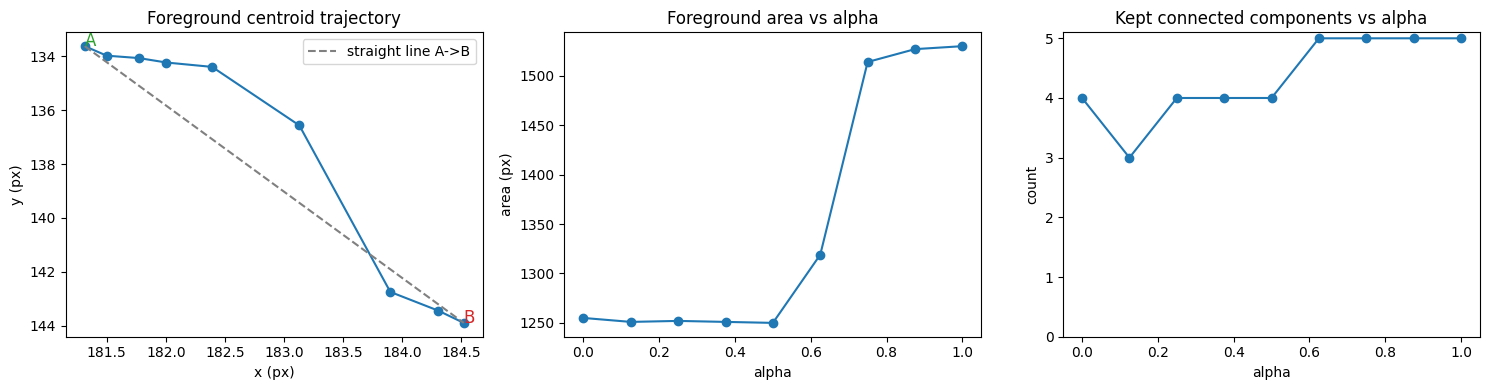

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(stats_df["cx"], stats_df["cy"], "o-", color="tab:blue")
axes[0].plot([stats_df["cx"].iloc[0], stats_df["cx"].iloc[-1]],
             [stats_df["cy"].iloc[0], stats_df["cy"].iloc[-1]], "--", color="gray", label="straight line A->B")
axes[0].annotate("A", (stats_df["cx"].iloc[0], stats_df["cy"].iloc[0]), color="tab:green", fontsize=12)
axes[0].annotate("B", (stats_df["cx"].iloc[-1], stats_df["cy"].iloc[-1]), color="tab:red", fontsize=12)
axes[0].invert_yaxis()
axes[0].set_title("Foreground centroid trajectory")
axes[0].set_xlabel("x (px)")
axes[0].set_ylabel("y (px)")
axes[0].legend()

axes[1].plot(stats_df["alpha"], stats_df["area"], "o-")
axes[1].set_title("Foreground area vs alpha")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("area (px)")

axes[2].plot(stats_df["alpha"], stats_df["n_components"], "o-")
axes[2].set_title("Kept connected components vs alpha")
axes[2].set_xlabel("alpha")
axes[2].set_ylabel("count")
axes[2].set_ylim(bottom=0)

fig.tight_layout()

## Optional: interactive alpha explorer

Requires `ipywidgets`. Drag the slider to inspect any interpolation point on demand instead of only the fixed
`alphas` grid above.

In [15]:
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError as exc:
    print(f"ipywidgets not available, skipping interactive explorer: {exc}")
else:
    def show_alpha(alpha=0.5):
        dec_mask = decode(lerp(z_mask_a, z_mask_b, alpha))
        dec_image = decode(lerp(z_image_a, z_image_b, alpha))
        fig, axes = plt.subplots(1, 2, figsize=(6, 3))
        axes[0].imshow(to_display(dec_mask), cmap="gray")
        axes[0].set_title("mask")
        axes[1].imshow(to_display(dec_image), cmap="gray")
        axes[1].set_title("image")
        for ax in axes:
            ax.axis("off")
        fig.suptitle(f"alpha={alpha:.3f}")
        plt.show()

    widgets.interact(show_alpha, alpha=widgets.FloatSlider(min=0.0, max=1.0, step=0.01, value=0.5))

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, step=0.01), Output()), _dom_classes…

## How to read the result

- If the mask strip shows a single vertebra-shaped blob sliding and deforming smoothly from A's position to B's,
  with the centroid plot close to the straight A->B line, that supports the "geometric continuity" claim.
- If instead you see two separate faint structures near A's and B's original positions (most visible around
  `alpha=0.5`), with area closer to the *sum* of A's and B's areas rather than a smooth blend, that supports the
  crossfade hypothesis instead.
- Real outputs can land in between (e.g. parts of the shape sliding while others fade) — the point of this notebook
  is to *look*, not to assume either extreme. Change `preferred_video_id` / `pair_index` in the config cell to check
  whether the behavior is consistent across several frame pairs, including pairs with small vs. large `frame_gap`.